In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('q3_retail_promotions.csv')
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year']         = df['transaction_date'].dt.year
df['month']        = df['transaction_date'].dt.month
df['day_of_week']  = df['transaction_date'].dt.dayofweek   # 0=Monday, 6=Sunday
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print("New columns added:")
df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].head(8)

New columns added:


,transaction_date,year,month,day_of_week,is_month_end
0,2022-01-01,2022,1,5,0
1,2022-01-01,2022,1,5,0
2,2022-01-02,2022,1,6,0
3,2022-01-02,2022,1,6,0
4,2022-01-03,2022,1,0,0
5,2022-01-03,2022,1,0,0
6,2022-01-04,2022,1,1,0
7,2022-01-04,2022,1,1,0


## Task 1 — Date Feature Engineering
- `year`, `month`, `day_of_week` extracted from `transaction_date` to capture temporal patterns.
- `is_month_end`: Binary flag for the last week of the month (day ≥ 25), which often sees increased retail activity due to salary cycles.

In [ ]:
df_sorted = df.sort_values('transaction_date').reset_index(drop=True)

split_index = int(len(df_sorted) * 0.8)
train_df = df_sorted.iloc[:split_index]
test_df  = df_sorted.iloc[split_index:]

print(f"Train size: {len(train_df)} | Date range: {train_df['transaction_date'].min().date()} → {train_df['transaction_date'].max().date()}")
print(f"Test  size: {len(test_df)}  | Date range: {test_df['transaction_date'].min().date()} → {test_df['transaction_date'].max().date()}")

Train size: 960 | Date range: 2022-01-01 → 2024-06-11
Test  size: 240  | Date range: 2024-06-12 → 2024-12-31


## Task 2 — Why Random Split is Inappropriate for Time-Ordered Data

Time-series data has temporal order — future events depend on past events. A random split
would allow the model to "see" future data during training (data leakage), making test
performance unrealistically optimistic.

A temporal split preserves the natural order: the model is trained on older records and
evaluated on genuinely unseen future records, simulating real-world deployment conditions.

In [ ]:
feature_cols = ['store_size', 'location_type', 'promotion_type',
                'is_weekend', 'is_festival', 'competition_density',
                'month', 'day_of_week', 'is_month_end', 'year']

target_col = 'items_sold'

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test  = test_df[feature_cols]
y_test  = test_df[target_col]

categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols   = ['is_weekend', 'is_festival', 'competition_density',
                    'month', 'day_of_week', 'is_month_end', 'year']

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
    ('num', StandardScaler(), numerical_cols)
])

print("Preprocessor built ✓")
print(f"Categorical features: {categorical_cols}")
print(f"Numerical features:   {numerical_cols}")

Preprocessor built ✓
Categorical features: ['promotion_type', 'location_type', 'store_size']
Numerical features:   ['is_weekend', 'is_festival', 'competition_density', 'month', 'day_of_week', 'is_month_end', 'year']



Linear Regression
  RMSE : 27.13
  MAE  : 21.07

Random Forest
  RMSE : 31.19
  MAE  : 25.00


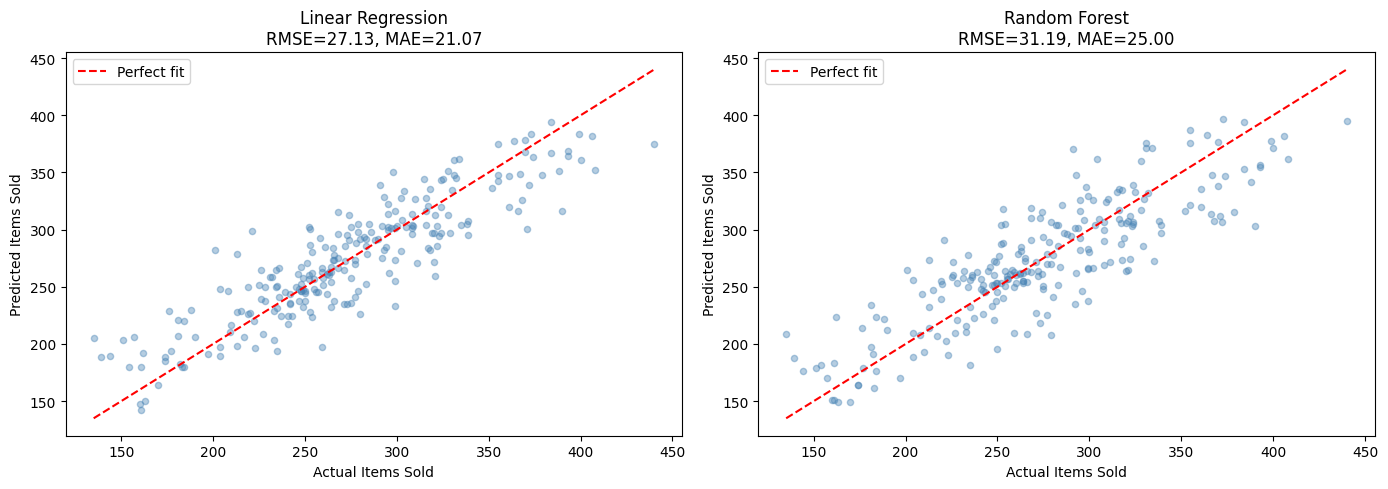

In [ ]:
model_configs = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (name, regressor) in enumerate(model_configs.items()):
    # Build full pipeline
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', regressor)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)

    results[name] = {'RMSE': round(rmse, 2), 'MAE': round(mae, 2), 'pipeline': pipe}

    print(f"\n{name}")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  MAE  : {mae:.2f}")

    # Parity plot
    axes[idx].scatter(y_test, y_pred, alpha=0.4, s=20, color='steelblue')
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect fit')
    axes[idx].set_title(f'{name}\nRMSE={rmse:.2f}, MAE={mae:.2f}')
    axes[idx].set_xlabel('Actual Items Sold')
    axes[idx].set_ylabel('Predicted Items Sold')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('parity_plots.png', dpi=100)
plt.show()

Top 5 Most Important Features:

                     Importance
is_festival              0.1736
store_size_small         0.1664
location_type_urban      0.1095
day_of_week              0.0930
competition_density      0.0640


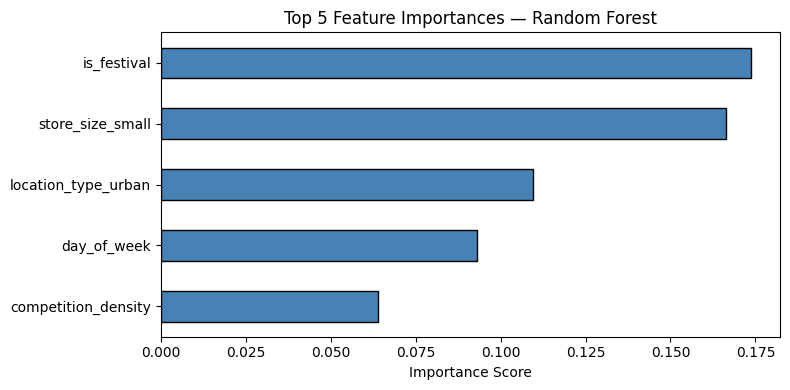

In [ ]:
rf_pipeline = results['Random Forest']['pipeline']
rf_model    = rf_pipeline.named_steps['model']

# Get feature names after one-hot encoding
ohe_features = rf_pipeline.named_steps['preprocessor']\
    .named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
all_features = ohe_features + numerical_cols

importances = pd.Series(rf_model.feature_importances_, index=all_features)
top5 = importances.sort_values(ascending=False).head(5)

print("Top 5 Most Important Features:\n")
print(top5.to_frame('Importance').round(4))

# Bar chart
top5.plot(kind='barh', figsize=(8, 4), color='steelblue', edgecolor='black')
plt.title('Top 5 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100)
plt.show()